In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

# import libraries:
import sys, os
os.environ['TF_USE_LEGACY_KERAS'] = '1'  # needed for tensorflow KERAS compatibility
os.environ['DISPLAY'] = 'inline'  # hack to get getdist working
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'../tensiometer')))
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND
import getdist
getdist.chains.print_load_details = False
import scipy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# tensorflow imports:
import tensorflow as tf
import tensorflow_probability as tfp

print(sys.path)

# import the tensiometer tools that we need:
import tensiometer
#from tensiometer.utilities import stats_utilities as utilities # error
from tensiometer import utilities
from tensiometer.synthetic_probability import synthetic_probability as sp

# getdist settings to ensure consistency of plots:
getdist_settings = {'ignore_rows': 0.4, 
                    'smooth_scale_2D': 0.3,
                    'smooth_scale_1D': 0.3,
                    }

2025-06-23 12:27:35.077759: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 12:27:35.124157: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-23 12:27:35.168844: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-23 12:27:35.181270: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-23 12:27:35.218395: I tensorflow/core/platform/cpu_feature_guar

['/auto_farm/farm_fs/mraveri/projects/marialuisa/tensiometer', '/home/mraveri/software/anaconda3/envs/mlg/lib/python39.zip', '/home/mraveri/software/anaconda3/envs/mlg/lib/python3.9', '/home/mraveri/software/anaconda3/envs/mlg/lib/python3.9/lib-dynload', '', '/home/mraveri/.local/lib/python3.9/site-packages', '/home/mraveri/.local/lib/python3.9/site-packages/tensorflow_probability-0.24.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/gast-0.4.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/pymanopt-0.2.5-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/sphinx_rtd_theme-3.0.1-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/joblib-1.4.2-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/dm_tree-0.1.8-py3.9-linux-x86_64.egg', '/home/mraveri/.local/lib/python3.9/site-packages/cloudpickle-3.1.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/absl_py-2.1.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-p

In [3]:
# ADD MY CHAINS:
# Loading samples
#PLANCK_ALL
#lcdm:
chain_lcdm = os.path.join('/home/mraveri/projects/andrea/tesi_magistrale/lcdm/planck_all', '1_lcdm_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/mraveri/projects/andrea/tesi_magistrale/w0wacdm/all_planck/first_attempt', '1_w0wa_planck_desidr2_des')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/mraveri/projects/andrea/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all/first_attempt', '1_EXP_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)

['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']
['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'w', 'wa', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8'

In [4]:
kwargs = {
          # flow settings:
          'pop_size': 1,
          'num_flows': 1,
          'epochs': 300,
          'transformation_type': 'spline',
          'autoregressive_type': 'masked',
          # feedback flags:
          'feedback': 1,
          'verbose': -1,
          'plot_every': 1000,
        }

spline_flow_lcdm = sp.flow_from_chain(samples_lcdm,  # parameter difference chain
                                 **kwargs)

* Initializing samples
    - time taken: 0.0178 seconds
* Initializing fixed bijector


2025-06-23 12:32:31.410218: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43598 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:31:00.0, compute capability: 8.6
2025-06-23 12:32:31.418369: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43598 MB memory:  -> device: 1, name: NVIDIA A40, pci bus id: 0000:4b:00.0, compute capability: 8.6
2025-06-23 12:32:31.422452: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43598 MB memory:  -> device: 2, name: NVIDIA A40, pci bus id: 0000:b1:00.0, compute capability: 8.6
2025-06-23 12:32:31.427305: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43598 MB memory:  -> device: 3, name: NVIDIA A40, pci bus id: 0000:ca:00.0, compute capability: 8.6


    - time taken: 11.6764 seconds
* Initializing trainable bijector
    range_max: 5.0
    max range: 14.209240913391113
    new range_max: 15.209241
    - time taken: 6.3976 seconds
* Initializing training dataset
    - time taken: 9.4545 seconds
* Initializing transformed distribution
    - time taken: 0.0374 seconds
* Initializing loss function
    - time taken: 0.0002 seconds
* Initializing training model
    - Compiling model
    - time taken: 0.1393 seconds
    - time taken: 36.0248 seconds
* Training
    - Compiling model
    - time taken: 0.1177 seconds


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

I0000 00:00:1750675004.095134 3690891 service.cc:146] XLA service 0x7ef520774350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750675004.096060 3690891 service.cc:154]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1750675004.096101 3690891 service.cc:154]   StreamExecutor device (1): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1750675004.096133 3690891 service.cc:154]   StreamExecutor device (2): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1750675004.096156 3690891 service.cc:154]   StreamExecutor device (3): NVIDIA A40, Compute Capability 8.6
2025-06-23 12:36:44.110658: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-06-23 12:36:44.265515: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
I0000 00:00:1750675004.483183 3690891 device_compiler.h:1

In [5]:
spline_flow_w0wa = sp.flow_from_chain(samples_w0wa,  # parameter difference chain
                                 **kwargs)

* Initializing samples
    - time taken: 0.0434 seconds
* Initializing fixed bijector
    - time taken: 1.2570 seconds
* Initializing trainable bijector
    range_max: 5.0
    max range: 12.593892097473145
    new range_max: 13.593892
    - time taken: 4.0463 seconds
* Initializing training dataset
    - time taken: 8.3900 seconds
* Initializing transformed distribution
    - time taken: 0.0243 seconds
* Initializing loss function
    - time taken: 0.0001 seconds
* Initializing training model
    - Compiling model
    - time taken: 0.0986 seconds
    - time taken: 24.1955 seconds
* Training
    - Compiling model
    - time taken: 0.0936 seconds


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [6]:
spline_flow_exp = sp.flow_from_chain(samples_exp,  # parameter difference chain
                                 **kwargs)

* Initializing samples
    - time taken: 0.0840 seconds
* Initializing fixed bijector
    - time taken: 1.3247 seconds
* Initializing trainable bijector
    range_max: 5.0
    max range: 12.918124198913574
    new range_max: 13.918124
    - time taken: 4.0305 seconds
* Initializing training dataset
    - time taken: 8.3851 seconds
* Initializing transformed distribution
    - time taken: 0.0256 seconds
* Initializing loss function
    - time taken: 0.0001 seconds
* Initializing training model
    - Compiling model
    - time taken: 0.1161 seconds
    - trainable parameters : 367200
    - number of data values: 271584
    - time taken: 26.1004 seconds
* Training
    - Compiling model
    - time taken: 0.0966 seconds


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

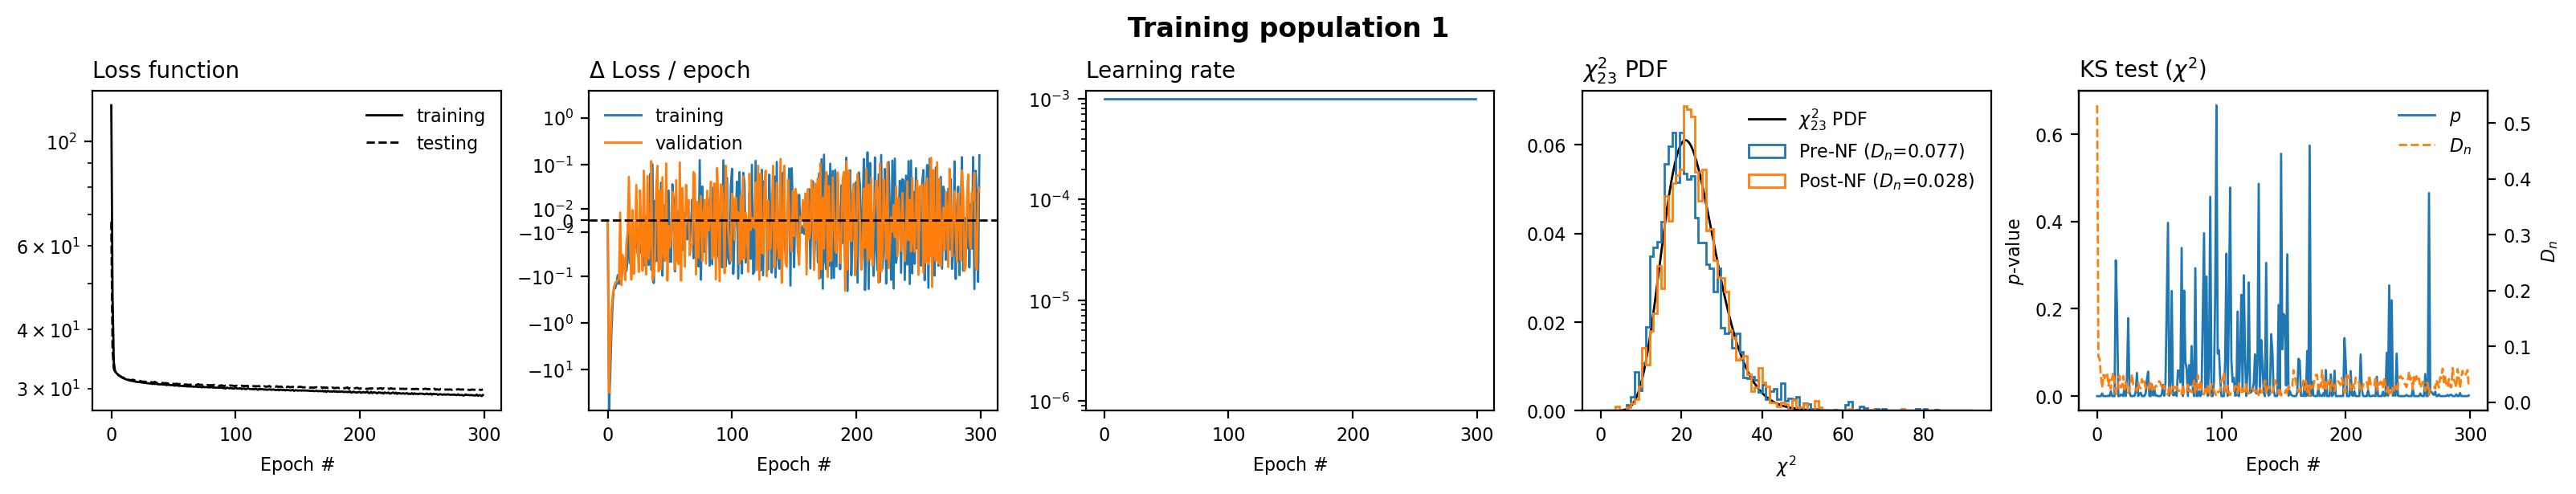

In [7]:
# we can plot training summaries to make sure training went smoothly:
spline_flow_lcdm.training_plot()

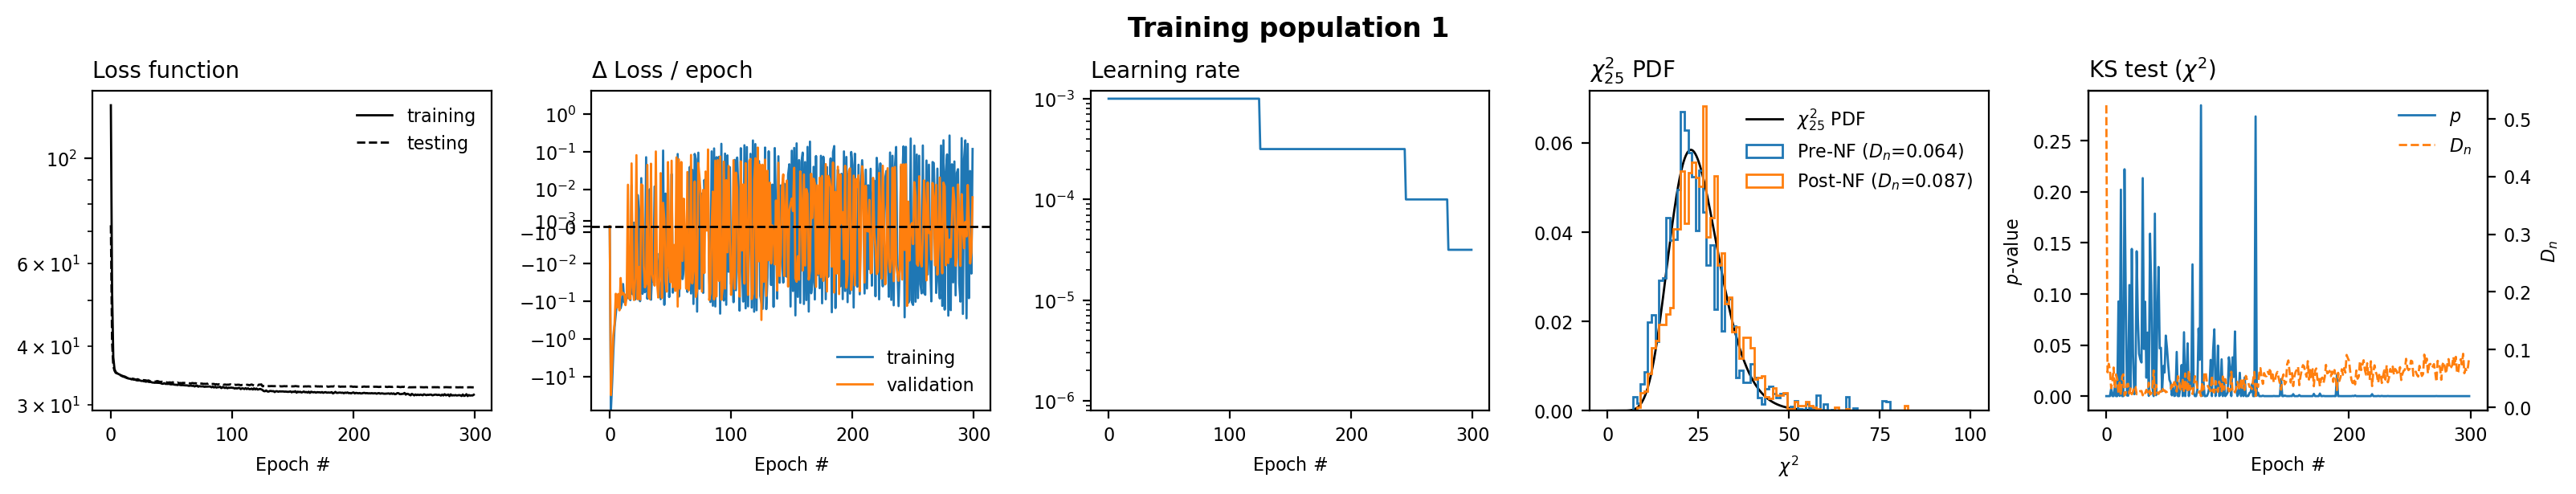

In [8]:
# we can plot training summaries to make sure training went smoothly:
spline_flow_w0wa.training_plot()

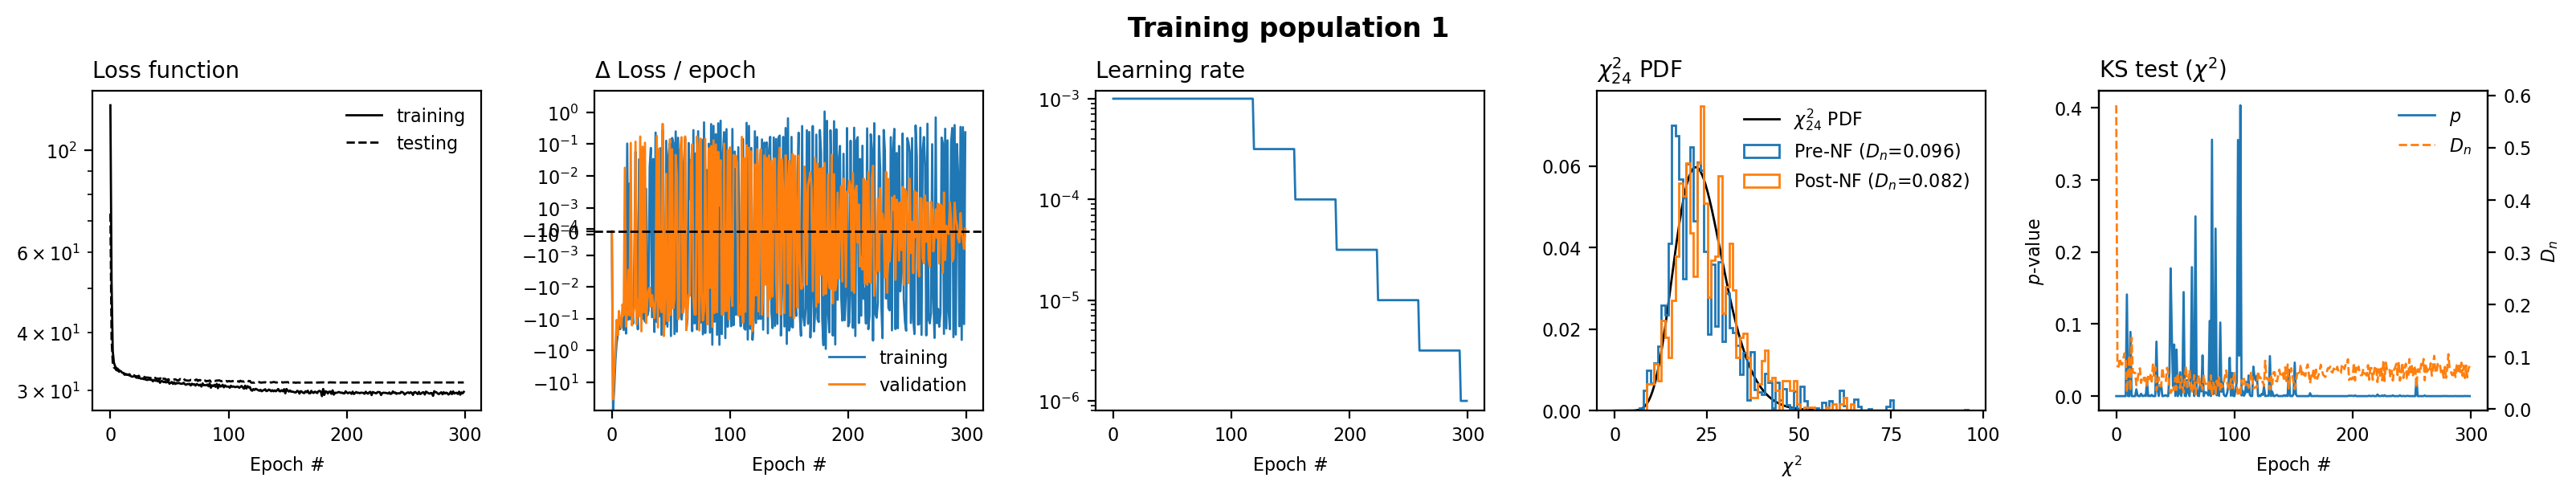

In [9]:
# we can plot training summaries to make sure training went smoothly:
spline_flow_exp.training_plot()

In [10]:
ev_lcdm, eer_lcdm = spline_flow_lcdm.evidence()
print(f'log(Z) LCDM = {ev_lcdm} +- {eer_lcdm}')

log(Z) LCDM = -16242.0166015625 +- 2.7152795791625977


In [11]:
ev_w0wa, eer_w0wa = spline_flow_w0wa.evidence()
print(f'log(Z) w0wa = {ev_w0wa} +- {eer_w0wa}')

log(Z) w0wa = -16239.9580078125 +- 2.823509931564331


In [12]:
ev_exp, eer_exp = spline_flow_exp.evidence()
print(f'log(Z) EFT_exp = {ev_exp} +- {eer_exp}')

log(Z) EFT_exp = -16236.7802734375 +- 2.824738025665283
